In [ ]:
install.packages("igraph", repos = "https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(igraph)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [ ]:
g <- graph(
  c(1,2, 2,3, 3,4, 4,1),
  directed = FALSE,
  n = 7
)

print(g)

Warning message:
“`graph()` was deprecated in igraph 2.1.0.
ℹ Please use `make_graph()` instead.”


IGRAPH 7080ee2 U--- 7 4 -- 
+ edges from 7080ee2:
[1] 1--2 2--3 3--4 1--4


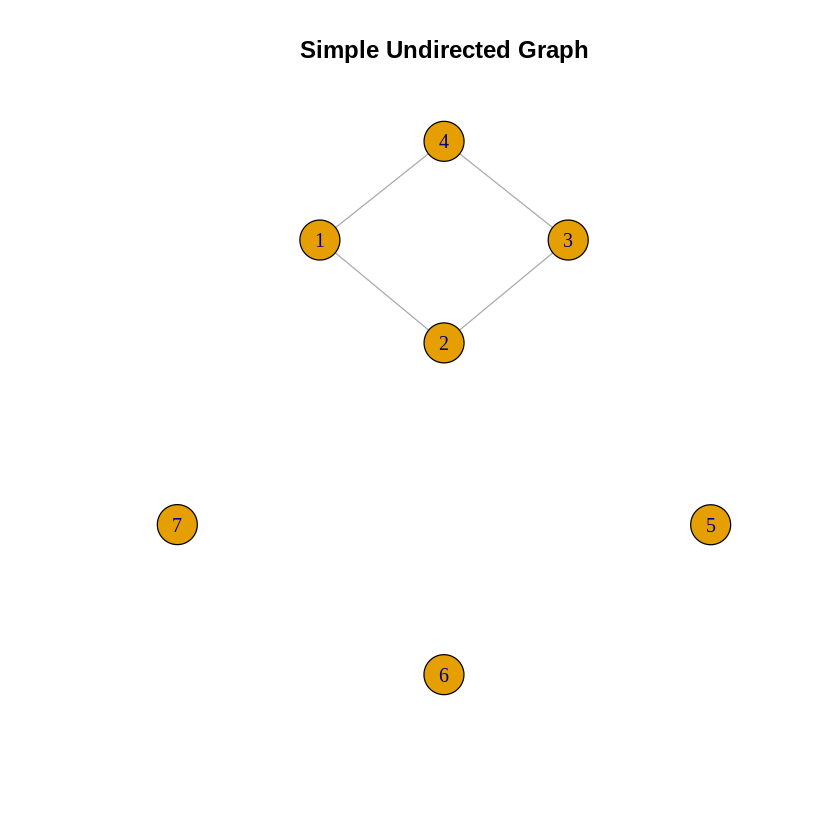

In [ ]:
plot(
  g,
  main = "Simple Undirected Graph"
)

In [ ]:
g1 <- graph(
  c(
    "Amy", "Ram",
    "Ram", "Li",
    "Li", "Amy",
    "Amy", "Li",
    "Kate", "Li"
  ),
  directed = TRUE
)

print(g1)

IGRAPH b8f81a1 DN-- 4 5 -- 
+ attr: name (v/c)
+ edges from b8f81a1 (vertex names):
[1] Amy ->Ram Ram ->Li  Li  ->Amy Amy ->Li  Kate->Li 


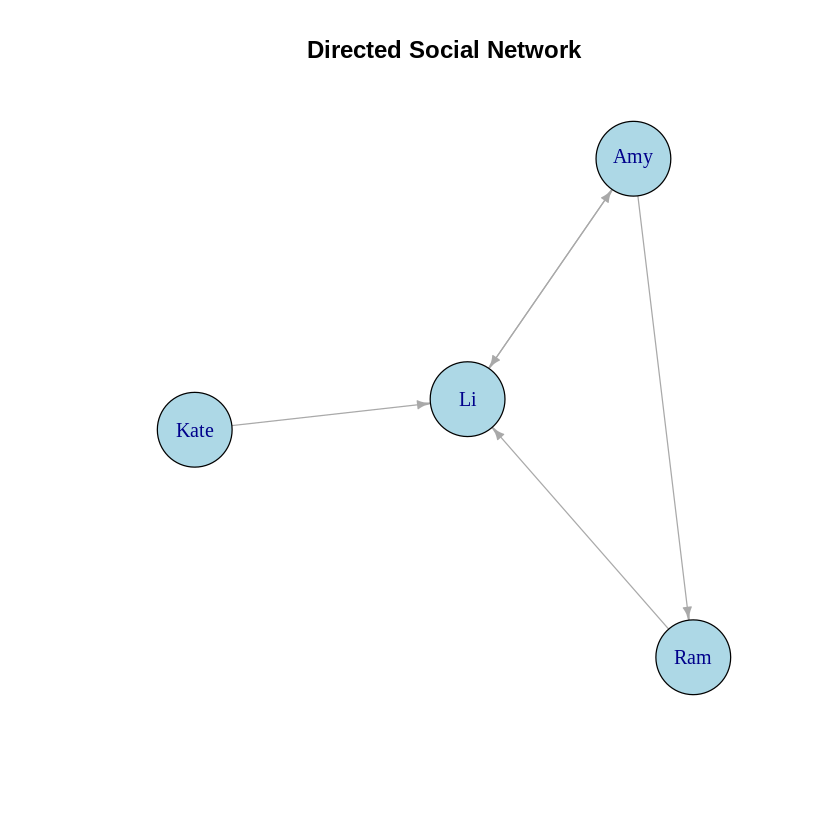

In [ ]:
plot(
  g1,
  main = "Directed Social Network",
  vertex.color = "lightblue",
  vertex.size = 30,
  edge.arrow.size = 0.5
)

In [ ]:
degree(g1, mode = "all")

Amy  Ram   Li Kate 
   3    2    4    1

In [ ]:
degree(g1, mode = "in")

Amy  Ram   Li Kate 
   1    1    3    0

In [ ]:
diameter(
  g1,
  directed = FALSE,
  weights = NA
)

[1] 2

In [ ]:
edge_density(
  g1,
  loops = FALSE
)

[1] 0.4166667

In [ ]:
reciprocity(g1)

[1] 0.4

In [ ]:
closeness(
  g1,
  mode = "all",
  weights = NA
)

Amy       Ram        Li      Kate 
0.2500000 0.2500000 0.3333333 0.2000000

In [ ]:
betweenness(
  g1,
  directed = TRUE,
  weights = NA
)

Amy  Ram   Li Kate 
   2    0    3    0

In [ ]:
edge_betweenness(
  g1,
  directed = TRUE,
  weights = NA
)

[1] 3 2 5 1 3

In [ ]:
data <- read.csv(
  "https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv",
  header = TRUE
)

head(data)

,first,second,grade,spec
,<chr>,<chr>,<int>,<chr>
1,AA,DD,6,Y
2,AB,DD,6,R
3,AF,BA,6,Q
4,DD,DA,6,Q
5,CD,EC,6,X
6,DD,CE,6,Y


In [ ]:
y <- data.frame(
  data$first,
  data$second
)

head(y)

,data.first,data.second
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE


In [ ]:
net <- graph_from_data_frame(
  y,
  directed = TRUE
)

print(net)

IGRAPH cf65878 DN-- 52 290 -- 
+ attr: name (v/c)
+ edges from cf65878 (vertex names):
 [1] AA->DD AB->DD AF->BA DD->DA CD->EC DD->CE CD->FA CD->CC BA->AF CB->CA
[11] CC->CA CD->CA BC->CA DD->DA ED->AD AE->AC AB->BA CD->EC CA->CC EB->CC
[21] BF->CE BB->CD AC->AE CC->FB DC->BB BD->CF DB->DA DD->DA DB->DD BC->AF
[31] CF->DE DF->BF CB->CA BE->CA EA->CA CB->CA CB->CA CC->CA CD->CA BC->CA
[41] BF->CA CE->CA AC->AD BD->BE AE->DF CB->DF AC->DF AA->DD AA->DD AA->DD
[51] CD->DD AA->DD EE->DD CD->DD DB->AA AA->FC BE->CC EF->FD CF->FE BB->DD
[61] CD->DD BA->AB CD->EC BE->EE CE->CC CD->CC ED->CC BB->CC BE->CE DD->CE
[71] AC->CD ED->CD FF->CD AC->CD DD->CD DD->CD AE->GA AE->GA AE->GA AE->GA
+ ... omitted several edges


In [ ]:
V(net)$label <- V(net)$name

V(net)$label

[1] "AA" "AB" "AF" "DD" "CD" "BA" "CB" "CC" "BC" "ED" "AE" "CA" "EB" "BF" "BB"
[16] "AC" "DC" "BD" "DB" "CF" "DF" "BE" "EA" "CE" "EE" "EF" "FF" "FD" "GB" "GC"
[31] "GD" "AD" "KA" "KF" "LC" "DA" "EC" "FA" "FB" "DE" "FC" "FE" "GA" "GE" "KB"
[46] "KC" "KD" "KE" "LB" "LA" "LD" "LE"

In [ ]:
V(net)$degree <- degree(net)

V(net)$degree

[1] 18  9 23 36 40 26 24 50 21 27 15 62  7 12 23 27  2  4  8 12 23 20  8 10  6
[26]  8  1  8  1  1  1  9  3  3  1  7  3  1  1  2  1  2  5  1  1  1  1  1  1  1
[51]  1  1

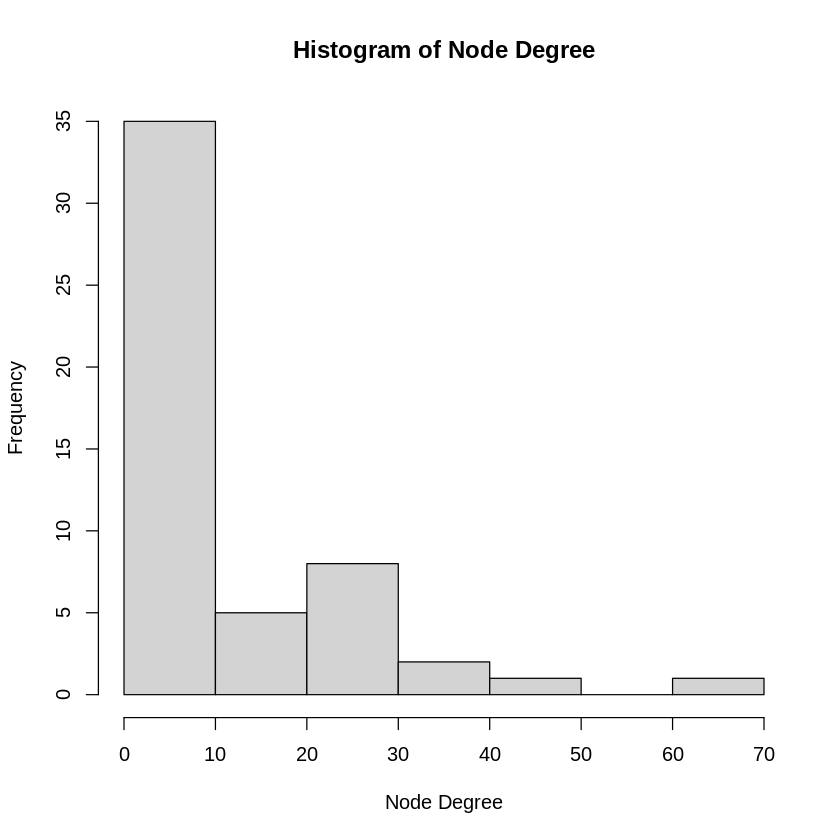

In [ ]:
hist(
  V(net)$degree,
  main = "Histogram of Node Degree",
  xlab = "Node Degree",
  ylab = "Frequency"
)

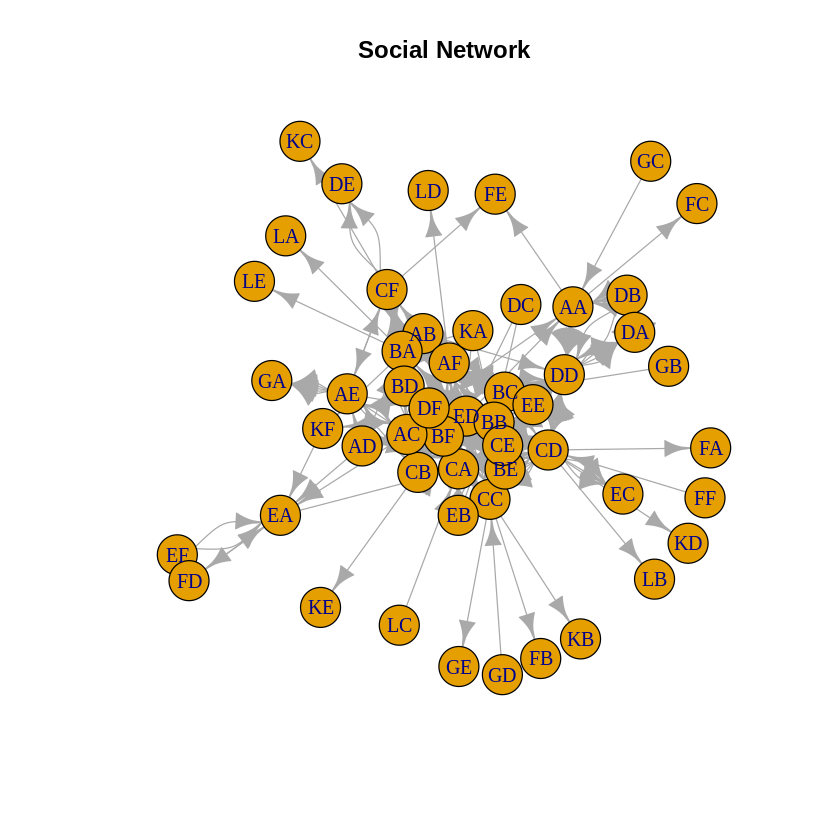

In [ ]:
plot(
  net,
  main = "Social Network"
)

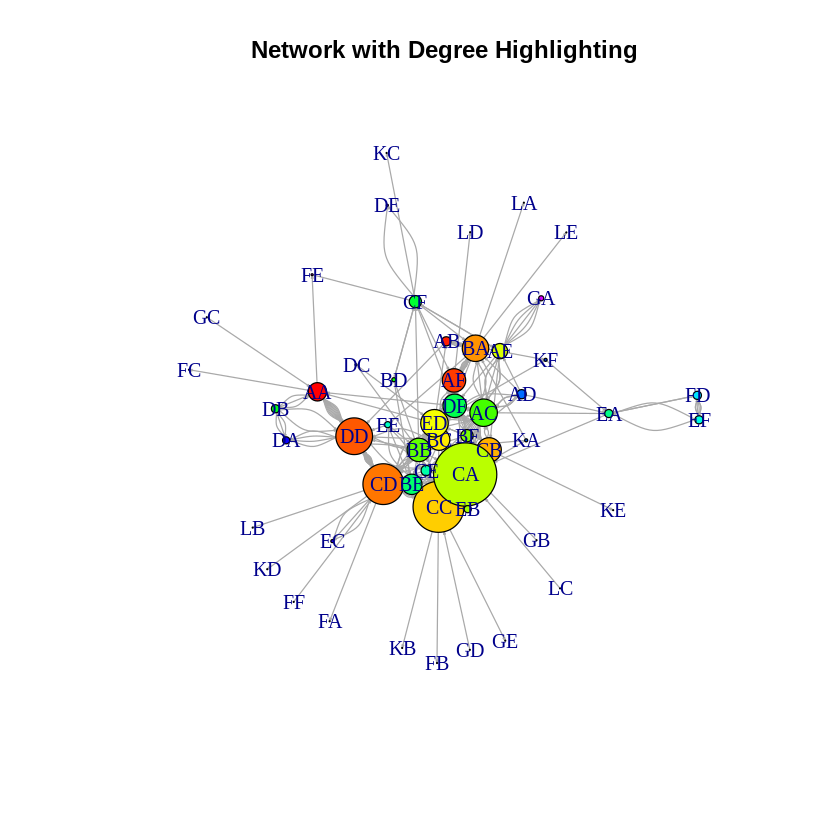

In [ ]:
set.seed(123)

plot(
  net,
  vertex.color = rainbow(vcount(net)),
  vertex.size = V(net)$degree * 0.4,
  edge.arrow.size = 0.1,
  layout = layout_with_fr(net),
  main = "Network with Degree Highlighting"
)

In [ ]:
hs <- hub_score(net)$vector

hs

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”


AA           AB           AF           DD           CD           BA 
0.0804280653 0.0130094958 0.0047314403 0.0125549578 0.2350165253 0.0323901300 
          CB           CC           BC           ED           AE           CA 
0.7145888159 1.0000000000 0.2321828382 0.0485835689 0.0794970773 0.0449495643 
          EB           BF           BB           AC           DC           BD 
0.1870058122 0.1272314500 0.1150808240 0.2093517929 0.0074555153 0.0130595971 
          DB           CF           DF           BE           EA           CE 
0.0173817606 0.0071028158 0.0250578677 0.2195271464 0.0569340883 0.0631908504 
          EE           EF           FF           FD           GB           GC 
0.0127382402 0.0011190982 0.0044854582 0.0004563724 0.0003594258 0.0002507046 
          GD           AD           KA           KF           LC           DA 
0.0063744634 0.0096431701 0.0627646253 0.0004418478 0.0568163870 0.0000000000 
          EC           FA           FB           DE           FC           FE 
0.0000000000 0.0000000000 0.0000000000 0.0000000000 0.0000000000 0.0000000000 
          GA           GE           KB           KC           KD           KE 
0.0000000000 0.0000000000 0.0000000000 0.0000000000 0.0000000000 0.0000000000 
          LB           LA           LD           LE 
0.0000000000 0.0000000000 0.0000000000 0.0000000000

In [ ]:
as <- authority_score(net)$vector

as

Warning message:
“`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead.”


AA           AB           AF           DD           CD           BA 
4.412541e-03 3.968841e-03 8.375004e-02 1.409698e-01 7.894656e-02 2.146204e-02 
          CB           CC           BC           ED           AE           CA 
3.660444e-03 1.121941e-01 6.326094e-03 4.799095e-02 1.524499e-02 1.000000e+00 
          EB           BF           BB           AC           DC           BD 
0.000000e+00 6.072030e-03 8.323026e-02 6.262068e-02 0.000000e+00 2.486679e-04 
          DB           CF           DF           BE           EA           CE 
0.000000e+00 8.146610e-03 1.925650e-01 1.095155e-01 7.776767e-03 2.437300e-02 
          EE           EF           FF           FD           GB           GC 
2.419075e-02 6.390996e-05 0.000000e+00 2.071608e-03 0.000000e+00 0.000000e+00 
          GD           AD           KA           KF           LC           DA 
0.000000e+00 1.806051e-02 0.000000e+00 2.156359e-03 0.000000e+00 3.583779e-03 
          EC           FA           FB           DE           FC           FE 
2.468362e-02 8.227873e-03 3.500976e-02 4.973358e-04 2.815768e-03 3.064436e-03 
          GA           GE           KB           KC           KD           KE 
1.391587e-02 3.500976e-02 3.500976e-02 2.486679e-04 8.227873e-03 2.501759e-02 
          LB           LA           LD           LE 
8.227873e-03 1.133971e-03 1.656466e-04 1.133971e-03

In [ ]:
hub_scores <- data.frame(
  Node = V(net)$name,
  Hub_Score = hs
)

hub_scores

,Node,Hub_Score
,<chr>,<dbl>
AA,AA,0.0804280653
AB,AB,0.0130094958
AF,AF,0.0047314403
DD,DD,0.0125549578
CD,CD,0.2350165253
BA,BA,0.0323901300
CB,CB,0.7145888159
CC,CC,1.0000000000
BC,BC,0.2321828382


In [ ]:
authority_scores <- data.frame(
  Node = V(net)$name,
  Authority_Score = as
)

authority_scores

,Node,Authority_Score
,<chr>,<dbl>
AA,AA,4.412541e-03
AB,AB,3.968841e-03
AF,AF,8.375004e-02
DD,DD,1.409698e-01
CD,CD,7.894656e-02
BA,BA,2.146204e-02
CB,CB,3.660444e-03
CC,CC,1.121941e-01
BC,BC,6.326094e-03


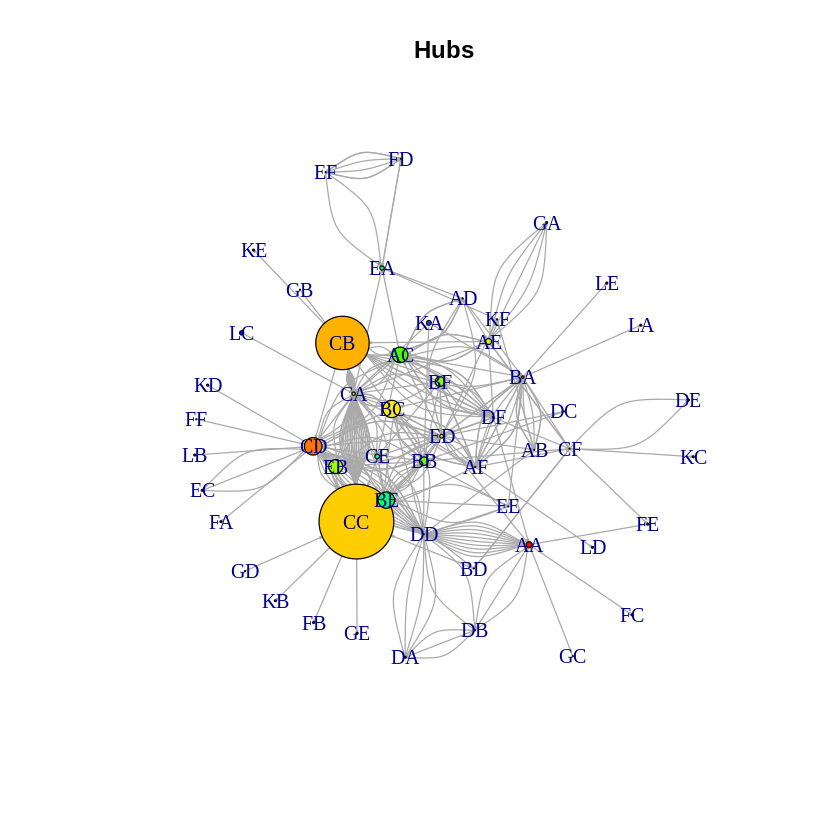

In [ ]:
set.seed(123)

plot(
  net,
  vertex.size = hs * 30,
  main = "Hubs",
  vertex.color = rainbow(vcount(net)),
  edge.arrow.size = 0.1,
  layout = layout_with_kk(net)
)

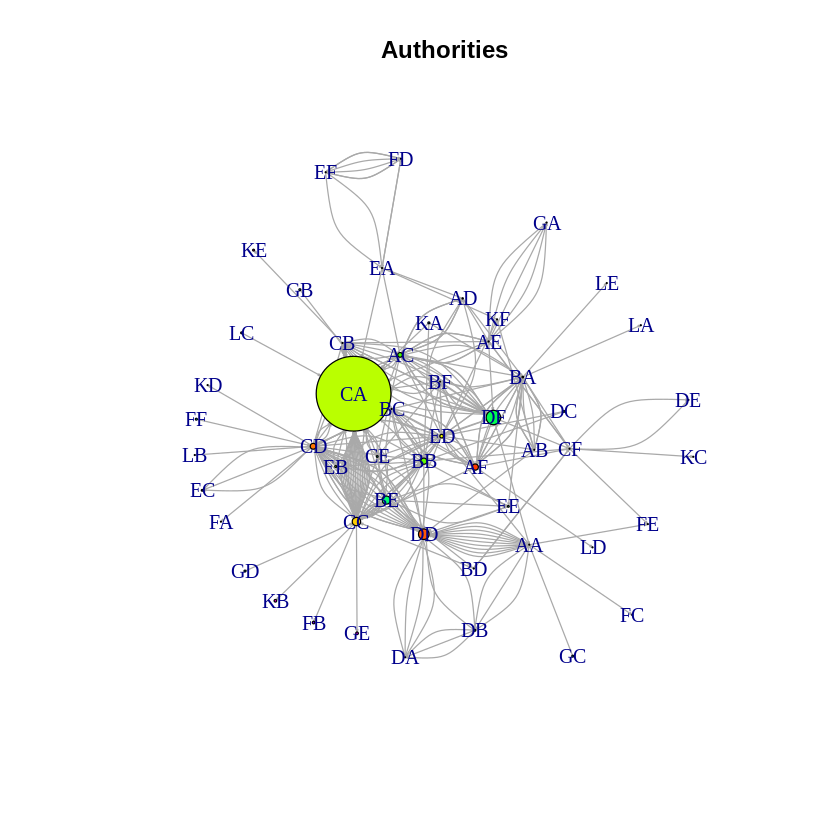

In [ ]:
set.seed(123)

plot(
  net,
  vertex.size = as * 30,
  main = "Authorities",
  vertex.color = rainbow(vcount(net)),
  edge.arrow.size = 0.1,
  layout = layout_with_kk(net)
)

In [ ]:
net_undirected <- graph_from_data_frame(
  y,
  directed = FALSE
)

print(net_undirected)

IGRAPH 2241d44 UN-- 52 290 -- 
+ attr: name (v/c)
+ edges from 2241d44 (vertex names):
 [1] AA--DD AB--DD AF--BA DD--DA CD--EC DD--CE CD--FA CD--CC AF--BA CB--CA
[11] CC--CA CD--CA BC--CA DD--DA ED--AD AE--AC AB--BA CD--EC CC--CA CC--EB
[21] BF--CE CD--BB AE--AC CC--FB BB--DC BD--CF DB--DA DD--DA DD--DB AF--BC
[31] CF--DE BF--DF CB--CA CA--BE CA--EA CB--CA CB--CA CC--CA CD--CA BC--CA
[41] CA--BF CA--CE AC--AD BD--BE AE--DF CB--DF AC--DF AA--DD AA--DD AA--DD
[51] DD--CD AA--DD DD--EE DD--CD AA--DB AA--FC CC--BE EF--FD CF--FE DD--BB
[61] DD--CD AB--BA CD--EC BE--EE CC--CE CD--CC CC--ED CC--BB BE--CE DD--CE
[71] CD--AC CD--ED CD--FF CD--AC DD--CD DD--CD AE--GA AE--GA AE--GA AE--GA
+ ... omitted several edges


In [ ]:
cnet <- cluster_edge_betweenness(
  net_undirected
)

print(cnet)

IGRAPH clustering edge betweenness, groups: 26, mod: 0.35
+ groups:
  $`1`
  [1] "AA" "DD" "CD" "ED" "DB" "DA" "EC"
  
  $`2`
  [1] "AB" "AF" "BA" "BC"
  
  $`3`
   [1] "CB" "CC" "CA" "EB" "BF" "BB" "DF" "BE" "CE" "EE"
  
  $`4`
  + ... omitted several groups/vertices


In [ ]:
membership(cnet)

AA AB AF DD CD BA CB CC BC ED AE CA EB BF BB AC DC BD DB CF DF BE EA CE EE EF 
 1  2  2  1  1  2  3  3  2  1  4  3  3  3  3  4  5  6  1  6  3  3  7  3  3  7 
FF FD GB GC GD AD KA KF LC DA EC FA FB DE FC FE GA GE KB KC KD KE LB LA LD LE 
 8  7  9 10 11  4 12  7 13  1  1 14 15  6 16 17  4 18 19 20 21 22 23 24 25 26 

In [ ]:
length(cnet)

[1] 26

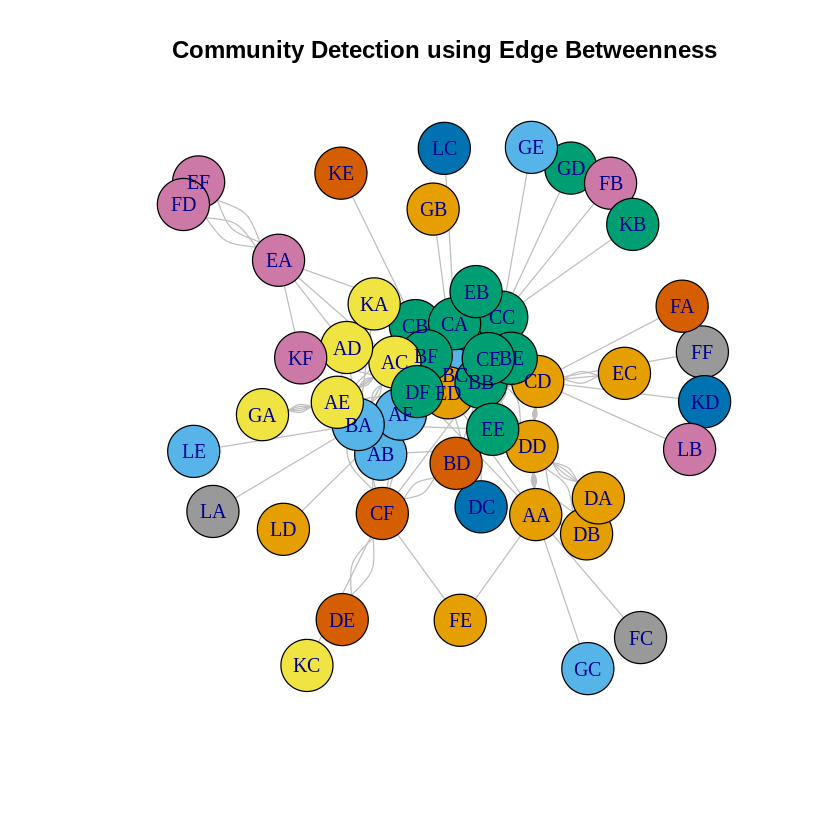

In [ ]:
plot(
  net_undirected,
  vertex.color = membership(cnet),
  vertex.size = 20,
  vertex.label = V(net_undirected)$name,
  edge.color = "gray",
  main = "Community Detection using Edge Betweenness"
)

In [ ]:
communities <- split(
  V(net_undirected)$name,
  membership(cnet)
)

communities

$`1`
[1] "AA" "DD" "CD" "ED" "DB" "DA" "EC"

$`2`
[1] "AB" "AF" "BA" "BC"

$`3`
 [1] "CB" "CC" "CA" "EB" "BF" "BB" "DF" "BE" "CE" "EE"

$`4`
[1] "AE" "AC" "AD" "GA"

$`5`
[1] "DC"

$`6`
[1] "BD" "CF" "DE"

$`7`
[1] "EA" "EF" "FD" "KF"

$`8`
[1] "FF"

$`9`
[1] "GB"

$`10`
[1] "GC"

$`11`
[1] "GD"

$`12`
[1] "KA"

$`13`
[1] "LC"

$`14`
[1] "FA"

$`15`
[1] "FB"

$`16`
[1] "FC"

$`17`
[1] "FE"

$`18`
[1] "GE"

$`19`
[1] "KB"

$`20`
[1] "KC"

$`21`
[1] "KD"

$`22`
[1] "KE"

$`23`
[1] "LB"

$`24`
[1] "LA"

$`25`
[1] "LD"

$`26`
[1] "LE"